<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/processamento_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from sklearn import datasets
import pandas as pd

categories = [
  # 'alt.atheism',
  'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  # 'comp.sys.mac.hardware',
  # 'comp.windows.x',
  # 'misc.forsale',
  # 'rec.autos',
  # 'rec.motorcycles',
  # 'rec.sport.baseball',
  # 'rec.sport.hockey',
  # 'sci.crypt',
  # 'sci.electronics',
  # 'sci.med',
  # 'sci.space',
  # 'soc.religion.christian',
  # 'talk.politics.guns',
  # 'talk.politics.mideast',
  # 'talk.politics.misc',
  # 'talk.religion.misc'
]

trn = datasets.fetch_20newsgroups(subset='train', categories=categories)


In [60]:

import pandas as pd

df = pd.DataFrame(trn.data, columns=['text'])
df['target'] = trn.target
df['target_names'] = df.target.apply(lambda x: trn.target_names[x])

df.head()


,text,target,target_names
0,From: ICH344@DJUKFA11.BITNET\nSubject: Wanted:...,2,comp.sys.ibm.pc.hardware
1,From: gay@venice.sedd.trw.com (Lance Gay)\nSub...,1,comp.os.ms-windows.misc
2,From: andrew@frip.WV.TEK.COM (Andrew Klossner)...,2,comp.sys.ibm.pc.hardware
3,From: sean@whiting.mcs.com (Sean Gum)\nSubject...,0,comp.graphics
4,From: bjorndahl@augustana.ab.ca\nSubject: Re: ...,1,comp.os.ms-windows.misc


In [61]:

from sklearn import model_selection

data, _ = model_selection.train_test_split(df, stratify=df.target, train_size=200, random_state=42)


data.target_names.value_counts()

,count
target_names,
comp.os.ms-windows.misc,67
comp.sys.ibm.pc.hardware,67
comp.graphics,66


In [62]:
print(f"Number of training samples: {data.shape[0]}")
print(f"Number of training labels:\n{data.target_names.value_counts()}")
print(f"First document's category name: {data.text.values[0]}")

Number of training samples: 200
Number of training labels:
target_names
comp.os.ms-windows.misc     67
comp.sys.ibm.pc.hardware    67
comp.graphics               66
Name: count, dtype: int64
First document's category name: From: holmes7000@iscsvax.uni.edu
Subject: WIn 3.0 ICON HELP PLEASE!
Organization: University of Northern Iowa
Lines: 10

I have win 3.0 and downloaded several icons and BMP's but I can't figure out
how to change the "wallpaper" or use the icons.  Any help would be appreciated.


Thanx,

-Brando

PS Please E-mail me




# Count Vectorizer

In [8]:
import nltk

fSTEM = False
fLEMMA = True


In [63]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


if fSTEM:
  # Initialize PorterStemmer
  stemmer = PorterStemmer()

  def stem_text(text):
      tokens = word_tokenize(text)
      stemmed_tokens = [stemmer.stem(token) for token in tokens]
      return " ".join(stemmed_tokens)

  print("PorterStemmer and stem_text function defined.")

  normed_data = [stem_text(doc) for doc in data.text]

if fLEMMA:
  import spacy
  # Load the spaCy language model
  nlp = spacy.load('en_core_web_sm')

  def lemmatize_corpus(corpus):
      lemmatized_texts = []
      for doc_text in corpus:
          # Process the document with the loaded nlp model
          doc = nlp(doc_text)
          # Extract lemmas, convert to lowercase, and filter for alphabetic tokens
          lemmas = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_space]
          # Join the lemmas back into a single string
          lemmatized_texts.append(' '.join(lemmas))
      return lemmatized_texts

  normed_data = lemmatize_corpus(data.text.tolist())


  if not fLEMMA and not fSTEM:
    normed_data = data.text.tolist()


  # print("First 5 lemmatized documents:")
  # for i, doc in enumerate(lemmatized_data[:5]):
  #     print(f"Document {i+1}: {doc}\n")



vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_df=0.975,
    min_df=0.025
)
trn_vec = vectorizer.fit_transform(normed_data)

# Print the learned vocabulary
print("Vocabulary:", trn_vec.shape[1])


# trn.data



Vocabulary: 673


In [64]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors = 10)

knn = knn.fit(trn_vec, data.target_names.tolist())

prediction = knn.predict(trn_vec)


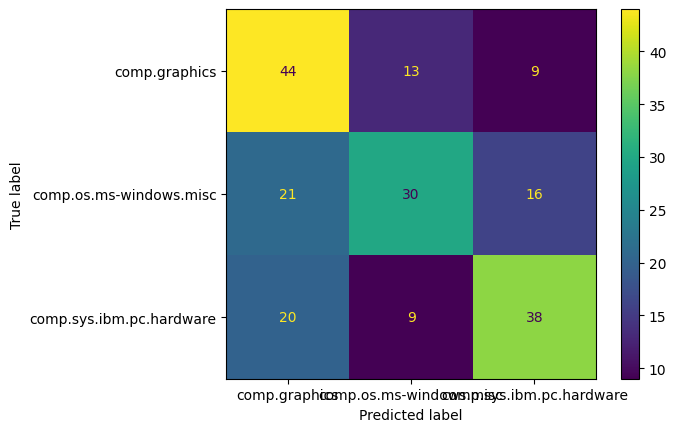

In [65]:
from sklearn import metrics

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(data.target_names.tolist(), prediction), display_labels=trn.target_names).plot()

In [16]:
print(metrics.classification_report(data.target_names, prediction, target_names=trn.target_names))

                    precision    recall  f1-score   support

     comp.graphics       0.61      0.87      0.72        68
      misc.forsale       0.84      0.60      0.70        68
talk.politics.guns       0.89      0.75      0.81        64

          accuracy                           0.74       200
         macro avg       0.78      0.74      0.74       200
      weighted avg       0.78      0.74      0.74       200



/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


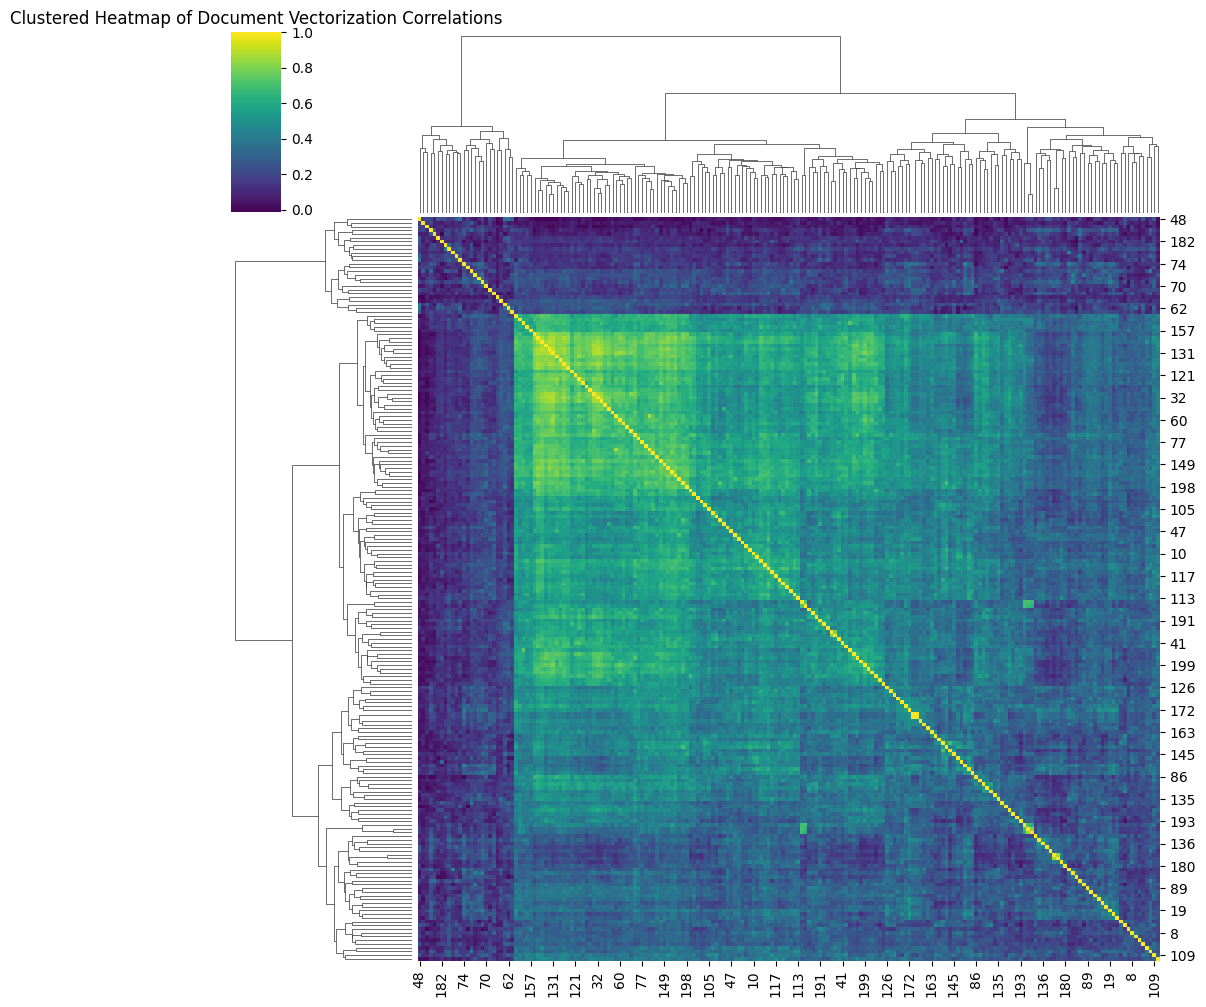

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn


C = np.corrcoef(trn_vec.toarray())

# Create a clustered heatmap
sns.clustermap(C, cmap='viridis', figsize=(10, 10))
plt.title('Clustered Heatmap of Document Vectorization Correlations')
plt.show()

# Codificação por TF-IDF

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_df=0.95,
    min_df=0.05,
    stop_words='english'
)
trn_vec = vectorizer.fit_transform(normed_data)


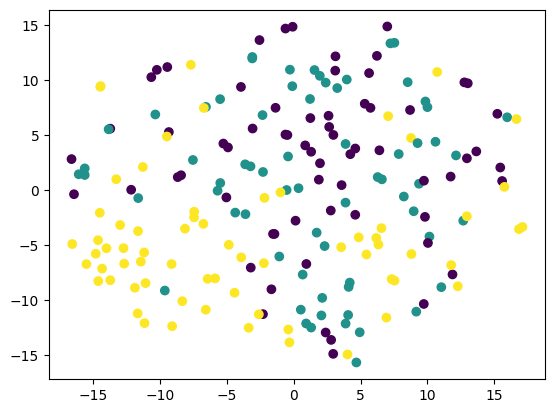

In [67]:
# Visualize with tsne
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# X = trn_vec.todense()
# X.shape

xtsne = TSNE(n_components=2).fit_transform(trn_vec.toarray())
plt.scatter(xtsne[:,0], xtsne[:,1], c=data.target)

                          precision    recall  f1-score   support

           comp.graphics       0.67      0.62      0.65        66
 comp.os.ms-windows.misc       0.65      0.73      0.69        67
comp.sys.ibm.pc.hardware       0.83      0.79      0.81        67

                accuracy                           0.71       200
               macro avg       0.72      0.71      0.71       200
            weighted avg       0.72      0.71      0.72       200



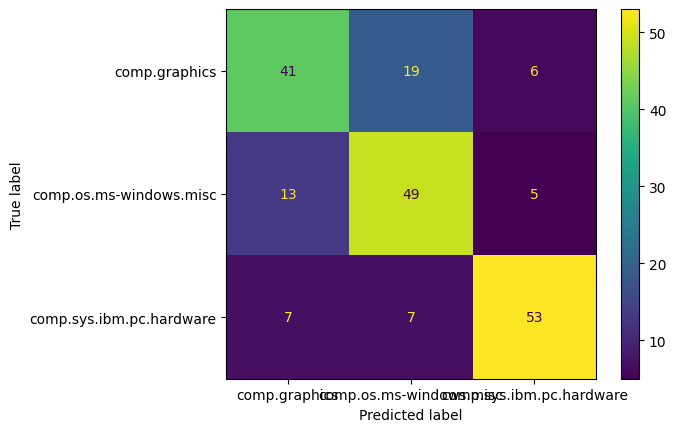

In [68]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors = 10)

knn = knn.fit(trn_vec, data.target_names.tolist())

prediction = knn.predict(trn_vec)

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(data.target_names.tolist(), prediction), display_labels=trn.target_names).plot()

print(metrics.classification_report(data.target_names, prediction, target_names=trn.target_names))

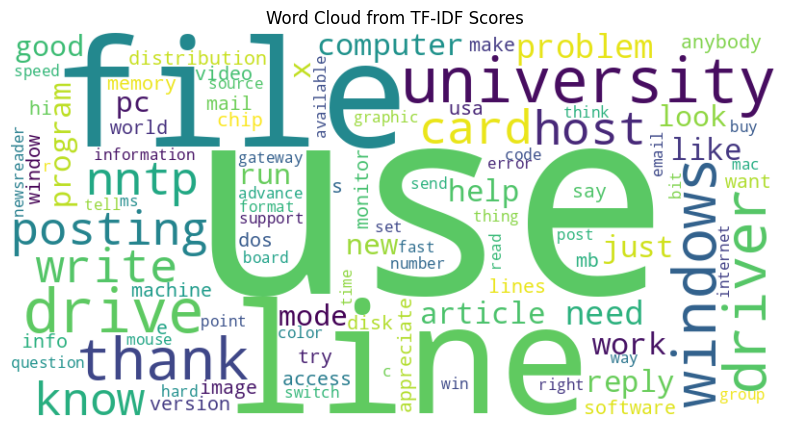

In [69]:
# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Get feature names (words) from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Sum the TF-IDF scores for each word across all documents
# trn_vec is a sparse matrix, convert to dense for summing
tfidf_scores = trn_vec.mean(axis=0).A1 # .A1 converts to a 1D numpy array

# Create a dictionary mapping words to their TF-IDF scores
word_tfidf_dict = dict(zip(feature_names, tfidf_scores))

# Create the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100, # Limit to top 100 words
    colormap='viridis'
).generate_from_frequencies(word_tfidf_dict)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from TF-IDF Scores')
plt.show()

,target_names
45,misc.forsale
1294,talk.politics.guns
1089,misc.forsale
1251,misc.forsale
653,talk.politics.guns
...,...
1685,talk.politics.guns
1090,misc.forsale
796,talk.politics.guns
1593,talk.politics.guns


<Figure size 800x1200 with 0 Axes>

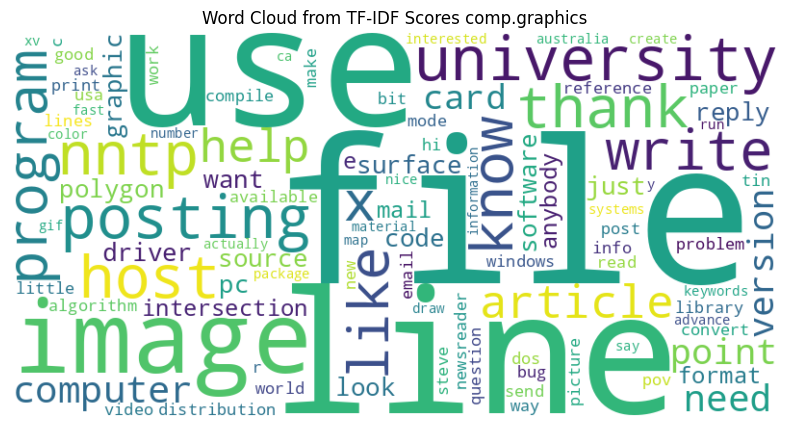

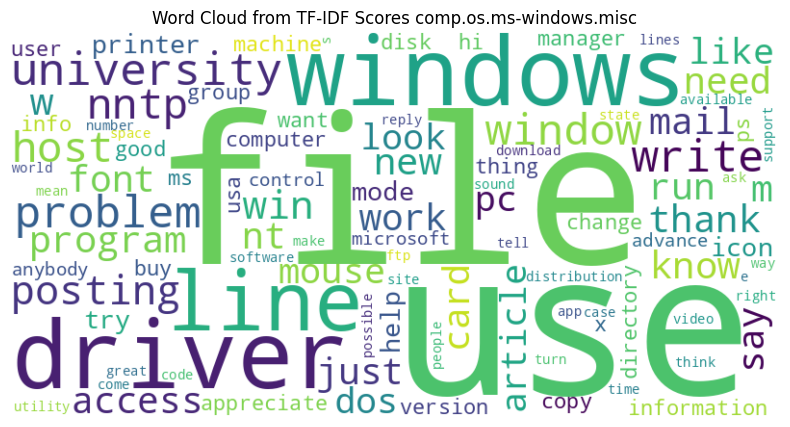

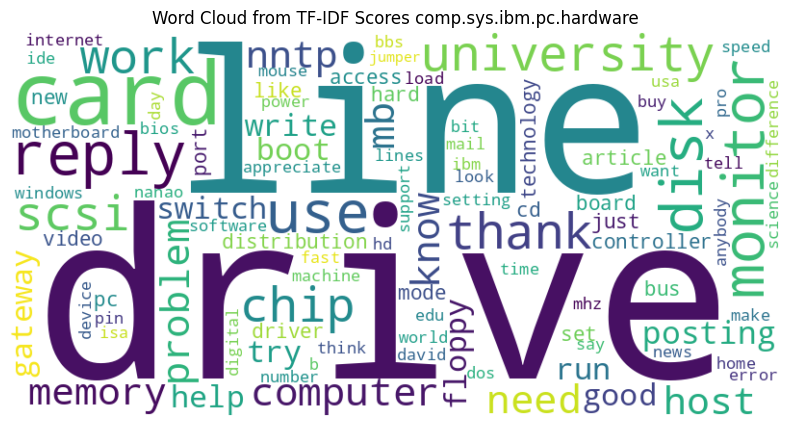

In [70]:
# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd



# Sum the TF-IDF scores for each word across all documents
# trn_vec is a sparse matrix, convert to dense for summing
plt.figure(figsize=(8,12))
for i, cat in enumerate(trn.target_names):
  X = np.array(normed_data)
  idx = data.target_names == cat


  vectorizer = TfidfVectorizer(
      token_pattern=r"(?u)\b[A-Za-z]+\b",
      max_df=0.95,
      min_df=0.05,
      stop_words='english'
  )

  trn_vec = vectorizer.fit_transform(X[idx])
  # Get feature names (words) from the TF-IDF vectorizer
  feature_names = vectorizer.get_feature_names_out()

  tfidf_scores = trn_vec.mean(axis=0).A1 # .A1 converts to a 1D numpy array

  # Create a dictionary mapping words to their TF-IDF scores
  word_tfidf_dict = dict(zip(feature_names, tfidf_scores))

  # Create the word cloud object
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      max_words=100, # Limit to top 100 words
      colormap='viridis'
  ).generate_from_frequencies(word_tfidf_dict)

  # Display the word cloud
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'Word Cloud from TF-IDF Scores {cat}')


                          precision    recall  f1-score   support

           comp.graphics       0.67      0.62      0.65        50
 comp.os.ms-windows.misc       0.70      0.66      0.68        56
comp.sys.ibm.pc.hardware       0.74      0.83      0.78        54

                accuracy                           0.71       160
               macro avg       0.70      0.70      0.70       160
            weighted avg       0.70      0.71      0.70       160

                          precision    recall  f1-score   support

           comp.graphics       0.58      0.44      0.50        16
 comp.os.ms-windows.misc       0.36      0.45      0.40        11
comp.sys.ibm.pc.hardware       0.86      0.92      0.89        13

                accuracy                           0.60        40
               macro avg       0.60      0.61      0.60        40
            weighted avg       0.61      0.60      0.60        40



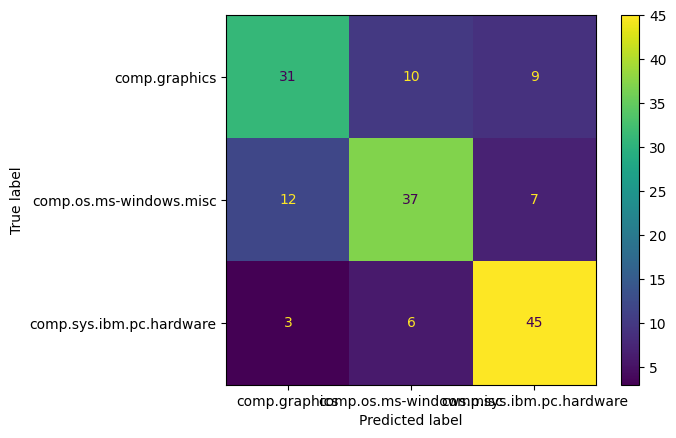

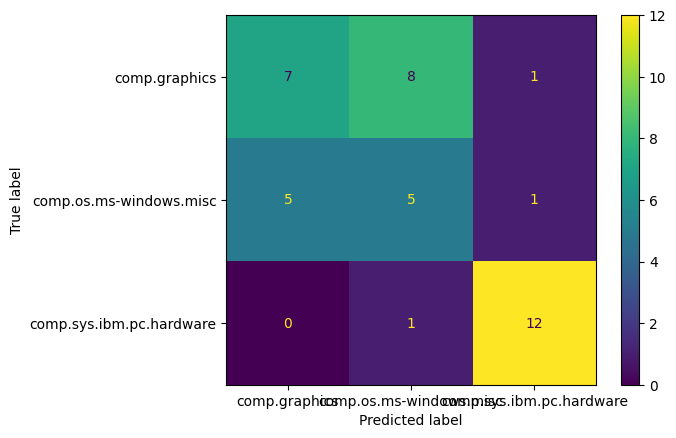

In [71]:

from sklearn import model_selection
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier

xtrain, xtest, ytrain, ytest = model_selection.train_test_split(normed_data, data.target, test_size=0.2, random_state=42)

ytrain

vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_df=0.95,
    min_df=0.05,
    stop_words='english'
)
trn_vec = vectorizer.fit_transform(xtrain)

tst_vec = vectorizer.transform(xtest)


knn = KNeighborsClassifier(n_neighbors = 10)

knn = knn.fit(trn_vec, ytrain)

# TREINO
prediction = knn.predict(trn_vec)

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(ytrain, prediction), display_labels=trn.target_names).plot()

print(metrics.classification_report(ytrain, prediction, target_names=trn.target_names))


# TEST

prediction = knn.predict(tst_vec)

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(ytest, prediction), display_labels=trn.target_names).plot()

print(metrics.classification_report(ytest, prediction, target_names=trn.target_names))


# Codifição por Text Embeddings de LLMs (opcional)

In [72]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Pre-trained sentence embedding model 'all-MiniLM-L6-v2' loaded successfully.")

train_emb = model.encode(xtrain)
test_emb = model.encode(xtest)
print(f"Sentence embeddings generated with shape: {train_emb.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-trained sentence embedding model 'all-MiniLM-L6-v2' loaded successfully.
Sentence embeddings generated with shape: (160, 384)


In [77]:
train_emb = sentence_embeddings

In [73]:


# Train the model using the training data
knn_model.fit(train_emb, ytrain)


KNeighborsClassifier(n_neighbors=10)

                          precision    recall  f1-score   support

           comp.graphics       0.76      0.76      0.76        50
 comp.os.ms-windows.misc       0.79      0.68      0.73        56
comp.sys.ibm.pc.hardware       0.76      0.87      0.81        54

                accuracy                           0.77       160
               macro avg       0.77      0.77      0.77       160
            weighted avg       0.77      0.77      0.77       160

                          precision    recall  f1-score   support

           comp.graphics       0.75      0.75      0.75        16
 comp.os.ms-windows.misc       0.60      0.55      0.57        11
comp.sys.ibm.pc.hardware       0.86      0.92      0.89        13

                accuracy                           0.75        40
               macro avg       0.74      0.74      0.74        40
            weighted avg       0.74      0.75      0.75        40



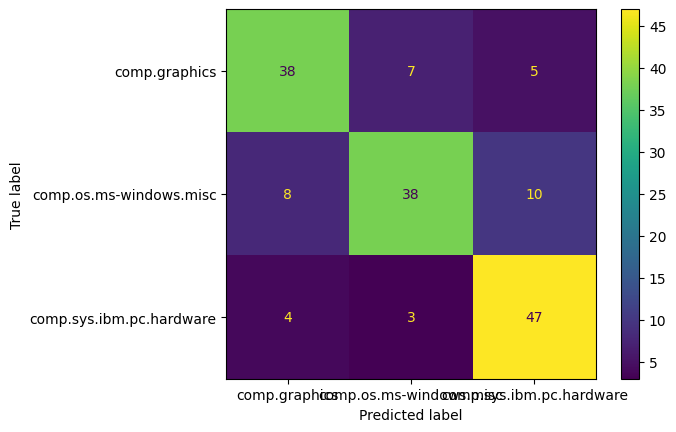

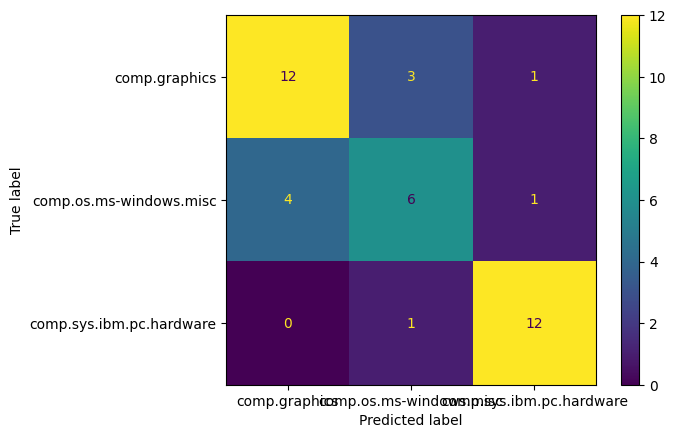

In [78]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier with a chosen number of neighbors
knn = KNeighborsClassifier(n_neighbors=10)
knn = knn.fit(train_emb, ytrain)

# TREINO
prediction = knn.predict(train_emb)

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(ytrain, prediction), display_labels=trn.target_names).plot()

print(metrics.classification_report(ytrain, prediction, target_names=trn.target_names))


# TEST

prediction = knn.predict(test_emb)

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(ytest, prediction), display_labels=trn.target_names).plot()

print(metrics.classification_report(ytest, prediction, target_names=trn.target_names))


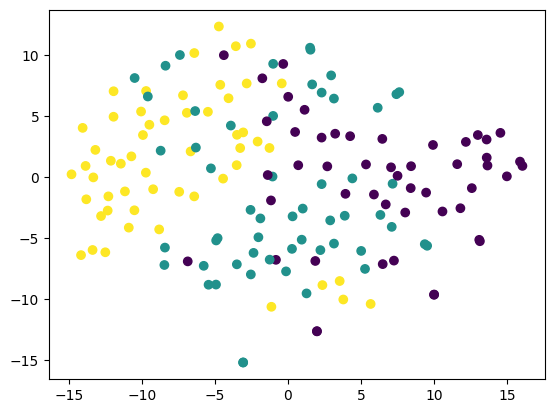

In [79]:
# Visualize with tsne
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# X = trn_vec.todense()
# X.shape

xtsne = TSNE(n_components=2).fit_transform(train_emb)
plt.scatter(xtsne[:,0], xtsne[:,1], c=ytrain)

# BACKUP

# Mini Exemplo

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the 09 first document.',
    'This is the second document',
    'And the third one.',
    'Is this the first document?',
]

# Use token_pattern to exclude digits (only match alphabetic words)
# vectorizer = CountVectorizer(token_pattern=r"(?u)\b[A-Za-z]+\b")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

# Print the learned vocabulary
print("Vocabulary:", vectorizer.get_feature_names_out())

# Print the numerical count matrix (dense representation for viewing)
print("Count Matrix:\n", X.toarray())

# trn.data

Vocabulary: ['09' 'and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
Count Matrix:
 [[1 0 1 1 1 0 0 1 0 1]
 [0 0 1 0 1 0 1 1 0 1]
 [0 1 0 0 0 1 0 1 1 0]
 [0 0 1 1 1 0 0 1 0 1]]


In [ ]:
# import sys
# !{sys.executable} -m pip install spacy
# !{sys.executable} -m spacy download en_core_web_sm

# print("spaCy installed and 'en_core_web_sm' model downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy installed and 'en_core_web_sm' model downloaded.


# Task
Install the `sentence-transformers` library to prepare for generating sentence embeddings.

## Install Sentence Transformers

### Subtask:
Install the `sentence-transformers` library, which is essential for generating high-quality sentence embeddings from text data.


**Reasoning**:
The subtask requires installing the `sentence-transformers` library, which can be done using pip.



In [35]:
pip install sentence-transformers

## Load Pre-trained Sentence Embedding Model

### Subtask:
Load a pre-trained sentence embedding model (e.g., 'all-MiniLM-L6-v2') to convert text into numerical vector representations.


**Reasoning**:
To load a pre-trained sentence embedding model, I need to import the `SentenceTransformer` class and then instantiate it with the specified model name.



In [36]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Pre-trained sentence embedding model 'all-MiniLM-L6-v2' loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Pre-trained sentence embedding model 'all-MiniLM-L6-v2' loaded successfully.


**Reasoning**:
The previous step successfully loaded the SentenceTransformer model. Now, I need to generate sentence embeddings for the text data using the loaded model. I will take the 'text' column from the `data` DataFrame and encode it using the `model.encode()` method, storing the result in a new variable.



In [37]:
sentence_embeddings = model.encode(data['text'].tolist())
print(f"Sentence embeddings generated with shape: {sentence_embeddings.shape}")

Sentence embeddings generated with shape: (200, 384)


## Split Data into Training and Test Sets

### Subtask:
Divide the generated sentence embeddings and their corresponding target labels (`data['target']`) into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
I need to import `train_test_split` from `sklearn.model_selection` to divide the data into training and testing sets, then split the `sentence_embeddings` and `data['target']` using the specified parameters, and finally print the shapes of the resulting sets.



In [38]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    sentence_embeddings, data['target'], test_size=0.2, random_state=42, stratify=data['target']
)

# Print the shapes of the resulting sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (160, 384)
X_test shape: (40, 384)
y_train shape: (160,)
y_test shape: (40,)


**Reasoning**:
Now that the data is split into training and testing sets, I need to train a classifier. I will use a KNeighborsClassifier as a common baseline for text classification tasks with vector representations.



In [39]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier with a chosen number of neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn_model.fit(X_train, y_train)

print("KNeighborsClassifier model trained successfully.")

KNeighborsClassifier model trained successfully.


**Reasoning**:
Now that the model has been trained, I need to evaluate its performance on the unseen test data by making predictions.



In [40]:
y_pred = knn_model.predict(X_test)
print("Predictions on the test set generated successfully.")

Predictions on the test set generated successfully.


**Reasoning**:
With predictions made, the next step is to evaluate the model's performance by generating a classification report, which provides precision, recall, f1-score, and support for each class.



In [41]:
from sklearn import metrics

print(metrics.classification_report(y_test, y_pred, target_names=data['target_names'].unique()))

                    precision    recall  f1-score   support

      misc.forsale       1.00      1.00      1.00        14
talk.politics.guns       1.00      0.92      0.96        13
     comp.graphics       0.93      1.00      0.96        13

          accuracy                           0.97        40
         macro avg       0.98      0.97      0.97        40
      weighted avg       0.98      0.97      0.97        40



**Reasoning**:
To visually represent the model's performance and identify misclassifications, I need to generate and plot a confusion matrix using `metrics.ConfusionMatrixDisplay`.



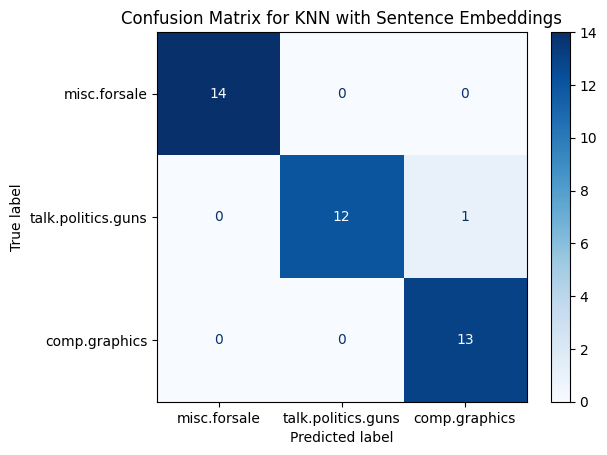

In [42]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# Create a display for the confusion matrix
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data['target_names'].unique())

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN with Sentence Embeddings')
plt.show()


## Final Task

### Subtask:
Summarize the model's performance based on the evaluation metrics.


## Summary:

### Data Analysis Key Findings

*   The `sentence-transformers` library was found to be pre-installed in the environment.
*   A pre-trained 'all-MiniLM-L6-v2' sentence embedding model was successfully loaded.
*   Sentence embeddings were generated for 200 text entries, resulting in numerical vector representations of shape (200, 384).
*   The data was successfully split into training (160 samples, shape (160, 384)) and testing (40 samples, shape (40, 384)) sets.
*   A `KNeighborsClassifier` model was trained using the sentence embeddings.
*   The model achieved a high overall accuracy of 0.97 on the test set.
*   The classification report indicated strong performance across all target classes, with high precision, recall, and f1-scores.
*   The confusion matrix visually confirmed the model's high accuracy and minimal misclassifications.

### Insights or Next Steps

*   The 'all-MiniLM-L6-v2' sentence embeddings are highly effective for this classification task, as demonstrated by the KNN model's excellent performance (97% accuracy).
*   Given the strong performance, future steps could include deploying this model or investigating its robustness with a larger and more diverse dataset.
